In [4]:
import requests
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import random
import pickle
import json
import os
from time import sleep
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

## Funciones auxiliares

- ### Diccionarios auxiliares
  En concreto hemos construido 4 diccionarios:

   - dict_character: clave: _url de personaje_ y de valor: _resultado del request de dicha URL_
   - dict_character_id: _id de personaje_ y de valor: _resultado del request de dicha URL en formato JSON_
   - dict_episodes_id: _id de episodio_ y de valor: _resultado del request de dicha URL en formato JSON_
   - dict_locations_id: _id de localización_ y de valor: _resultado del request de dicha URL en formato JSON_
  
  Al hacer esto podemos acceder más rapido a la información de cada endpoint. Esto es realmente útil para cuando en una columna tenemos "personajes" y la lista de sus endpoints, traducir esos endpoints a la información real del personaje.

In [ ]:
dict_character = {}
dict_character_id = {}

dict_episodes_id = {}

dict_locations_id = {}

# Conseguir los datos de todos las bases de datos, uno por uno
def get_all_slow(data_base_name):
    
    n_ = 0
    match data_base_name:
        case "character":
            n_ =827
        case "episode":
            n_ =52
        case "location":
            n_ =127
            
    for _id in range(n_):
        endpoint = f"https://rickandmortyapi.com/api/{data_base_name}/{_id + 1}"
        response = requests.get(endpoint)
        
        response_json = response.json()
        
        match data_base_name:
            case "character":
                dict_character[response_json["id"]] = response_json
            case "episode":
                dict_episodes_id[response_json["id"]] = response_json
            case "location":
                dict_locations_id[response_json["id"]] = response_json
                


def get_all_fast(data_base_name):
    total_data = []
    if data_base_name == "character":
        pages = 42
    elif data_base_name == "episode":
        pages = 3
    elif data_base_name == "location":
        pages = 7
    for page in range(pages):
        endpoint = f"https://rickandmortyapi.com/api/{data_base_name}/?page={page+1}"
        response = requests.get(endpoint)
        data = response.json()["results"]
        total_data.extend(data)
        
    return total_data

- ### Rellenamos los diccionarios

In [5]:
        
episodes = get_all_fast("episode")

locations = get_all_fast("location")

characters = get_all_fast("character")

for epi in episodes:
 dict_episodes_id[epi["id"]] = epi
 
for loc in locations:
 dict_locations_id[loc["id"]] = loc
 
for char in characters:
 dict_character[char["url"]] = char
 dict_character_id[char["id"]] = char

- ### Metodo para conseguir *TODA* la informacion a la vez
  Otro problema que hemos experimentado es que cuando queremos conseguir todos los datos de golpe, la página nos devuelve solo 20 filas como máximo. Esto se debe a que la info esta paginada en la api solo puediendo obtener la información total por paginas (grupos de 20).

In [6]:
def complete_data(dataframe_name):
    total_data = []
    if dataframe_name == "character":
        pages = 42
    elif dataframe_name == "episode":
        pages = 3
    elif dataframe_name == "location":
        pages = 7
    for page in range(pages):
        endpoint = f"https://rickandmortyapi.com/api/{dataframe_name}/?page={page+1}"
        response = requests.get(endpoint)
        data = response.json()["results"]
        total_data.extend(data)
    return total_data

In [78]:
originial_episodes = None
originial_locations = None
originial_characters = None

originial_episodes = pd.DataFrame(complete_data("episode"))
originial_locations = pd.DataFrame(complete_data("location"))
originial_characters = pd.DataFrame(complete_data("character"))


In [8]:
def transform_to_json(url_list, dict_name):
  dict_ = {}
  match dict_name:
    case "character":
      dict_ = dict_character_id
    case "episode":
      dict_ = dict_episodes_id
    case "location":
      dict_ = dict_locations_id
  toret = []
  for url in url_list:
    spited_url = url.split("/")
    id_from_url = int(spited_url[len(spited_url) -1])
    json_value = dict_[id_from_url]["id"]
    toret.append(json_value)
  return toret

In [79]:
originial_characters["episodes_id"] = [transform_to_json(list_urls, "episode") for list_urls in originial_characters["episode"]]
originial_episodes["characters_id"] = [transform_to_json(list_urls, "character") for list_urls in originial_episodes["characters"]]
originial_locations["residents_id"] = [transform_to_json(list_urls, "character") for list_urls in originial_locations["residents"]]
originial_locations["nº_residents"] = [len(list_urls) for list_urls in originial_locations["residents"]]

- ### Metodos auxiliares para formatear los data frames
  Usando el diccionario auxiliar conseguimos transformar todas las columnas que muestran la información como la URL del endpoint, a columnas donde se muestra los nombres, en este caso.
  También tenemos una funcion que elimina la columna con los url y nos pone los nombres en otra columna nueva

In [13]:
def fix_col_dict(data_frame: pd.DataFrame, nombre_col):
    
    datos =[]
    
    for fila in data_frame[nombre_col]:
        datos.append(fila["name"])
        
    data_frame[f"{nombre_col}_nueva"] = datos
    
    # Borramos la columna y la devolvemos
    return data_frame.drop(nombre_col, axis=1)

#Cambiamos URL por el nombre, usando el diccionario
def fix_url(dataframe, nombre_columna):
    
    lista_de_celdas = []
    
    for fila in dataframe[nombre_columna]:
        lista_de_nombres = []
        
        for url in fila:
            lista_de_nombres.append(dict_character[url]["name"])
        
        lista_de_celdas.append(lista_de_nombres)
        
    dataframe[nombre_columna] = lista_de_celdas

- #### Funciones de lectura y escritura

  Se guarda la info de los 3 _data Frames_ en un archivo binario para no tener que descargar los datos cada vez que ejecutemos el proyecto

In [14]:
file_path = "./transformed_data.pkl"

def save_file(transoformed_data):
 with open(file_path, "wb") as f:
  pickle.dump(transoformed_data, f)
  
def file_exists():
 return os.path.exists(file_path)

def load_file():
  with open(file_path, "rb") as f:
      loaded_data = pickle.load(f)
  return loaded_data

## Conseguir los datos

Este método consigue *TODA* información de las 3 bases de datos _(personajes, episodios, lugares)_, con el método de conseguir todas las páginas 

In [15]:
def fetch_data():
    
    datos_char = complete_data("character")
    datos_loc = complete_data("location")
    datos_epi = complete_data("episode")
    data = (datos_char,datos_loc,datos_epi)

    return data

## Formatear los datos
Una vez tenemos toda la información de las 3 bases de datos, formateamos su estructura para varias cosas: eliminar columnas con URLs por columnas con información, borrar y agregar nuevas columnas, etc.
Teniendo como resultado los 3 dataframes listos para estudiar y mostrar en gráficas.

In [16]:
def trasnform_data(total_data):
    
    data_characters, data_locations, data_episodes = total_data
    
    df_characters = pd.DataFrame(data_characters)
    
    # Arreglamos clounas de URL por el nombre
    df_characters = fix_col_dict(df_characters, "origin")
    df_characters = fix_col_dict(df_characters, "location")
    
    df_characters = df_characters.drop(["image","episode","url", "created"],axis = 1)
    
    df_locations = pd.DataFrame(data_locations)
    fix_url(df_locations, "residents")
    df_locations = df_locations.drop(["url", "created"],axis = 1)
    
    df_episodes = pd.DataFrame(data_episodes)
    fix_url(df_episodes, "characters")
    df_episodes = df_episodes.drop(["url", "created"],axis = 1)
    df_episodes["air_date"] = df_episodes["air_date"].apply(lambda x: datetime.strptime(x, "%B %d, %Y"))
    df_episodes["season"] = df_episodes["episode"].apply(lambda x: int(x[1:3]))
    df_episodes["episode_season"] = df_episodes["episode"].apply(lambda x: int(x[4:6]))
    df_episodes = df_episodes.drop(["episode"],axis = 1)
    columns = ['id', 'name', 'air_date', 'season', 'episode_season', 'characters']
    df_episodes = df_episodes[columns]
    
    return df_characters, df_locations, df_episodes

## Empieza el programa

Si tenemos los datos descargados con *complete_data()* y almacenados en un fichero binario, cargaremos directamente los datos del fichero. Mientras que si el fichero no existe, conseguiremos los datos con llamadas a la API de Rick y Morty

In [80]:
#EJECUCION 
if file_exists():
 transformed_data = load_file()
else:
 #Llamada a la api
 data = fetch_data()
 transformed_data = trasnform_data(data)

save_file(transformed_data)
df_characters, df_locations, df_episodes = transformed_data



## Estudio de personajes (_df_characters_)

- ### Personajes por especie

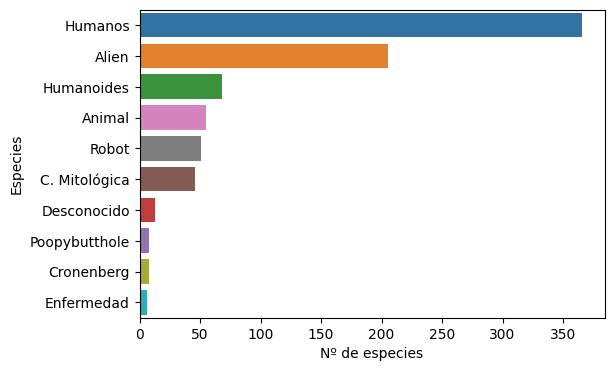

In [81]:
species_order = df_characters["species"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize = (6, 4))

sns.countplot(data=df_characters ,y="species", hue="species", order=species_order)
plt.yticks(ticks=[0,1,2,3, 4, 5, 6, 7, 8, 9], labels=["Humanos", "Alien", "Humanoides", "Animal", "Robot", "C. Mitológica", "Desconocido", "Poopybutthole", "Cronenberg", "Enfermedad"])

plt.ylabel("Especies")
plt.xlabel("Nº de especies")
plt.show()

- ### Estado de personajes por especie (Muerto, Vivo, Desconocido)

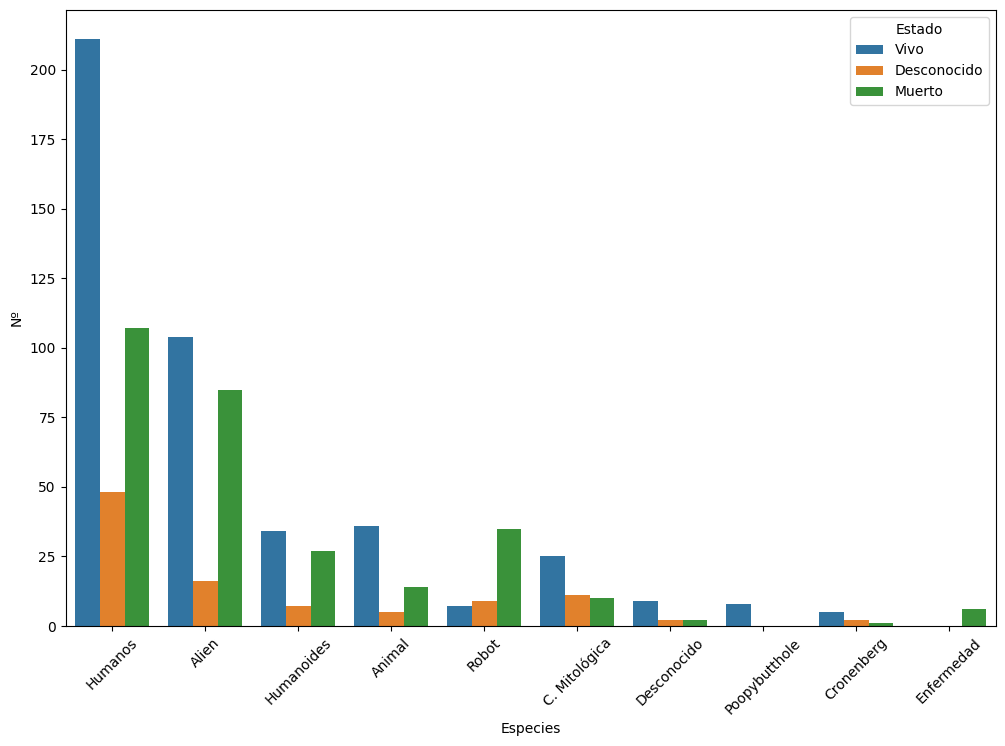

In [82]:

fig, ax = plt.subplots(figsize = (12, 8))

sns.countplot(data=df_characters ,x="species",hue="status", order=species_order)

plt.xticks(rotation=45)

plt.xticks(ticks=[0,1,2,3, 4, 5, 6, 7, 8, 9], labels=["Humanos", "Alien", "Humanoides", "Animal", "Robot", "C. Mitológica", "Desconocido", "Poopybutthole", "Cronenberg", "Enfermedad"])

plt.xlabel("Especies")

plt.ylabel("Nº")

plt.legend(labels=["Vivo", "Desconocido", "Muerto"], title="Estado")

plt.show()



- ### Lugares de origen de personajes

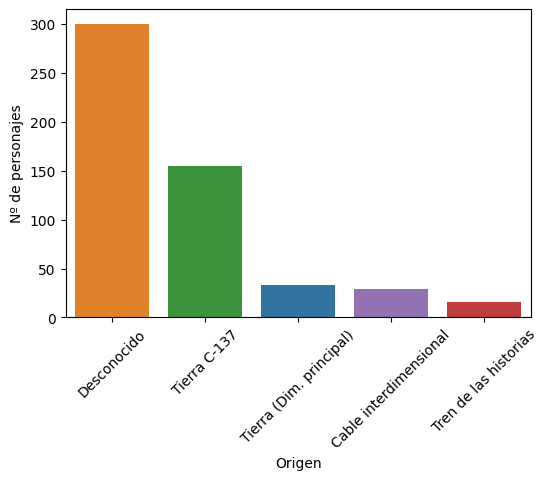

In [83]:
fig, ax = plt.subplots(figsize = (6, 4))

datos_planetas = df_characters["origin_nueva"].value_counts().index[:5].tolist()

to_graph = df_characters[df_characters["origin_nueva"].isin(datos_planetas)]

orden_origenes = to_graph["origin_nueva"].value_counts().index.tolist()

my_graph = df_characters["origin_nueva"].value_counts()

sns.countplot(data=to_graph,x=to_graph["origin_nueva"].sort_values(), hue="origin_nueva", order=orden_origenes)

plt.xticks(rotation=45)

plt.xticks(ticks=[0,1,2,3,4], labels=["Desconocido", "Tierra C-137", "Tierra (Dim. principal)", "Cable interdimensional", "Tren de las historias"])

plt.xlabel("Origen")
plt.ylabel("Nº de personajes")

plt.xticks()
plt.show()


- ### Género de todos los personajes
  Analizamos el género de los 826 personajes distintos

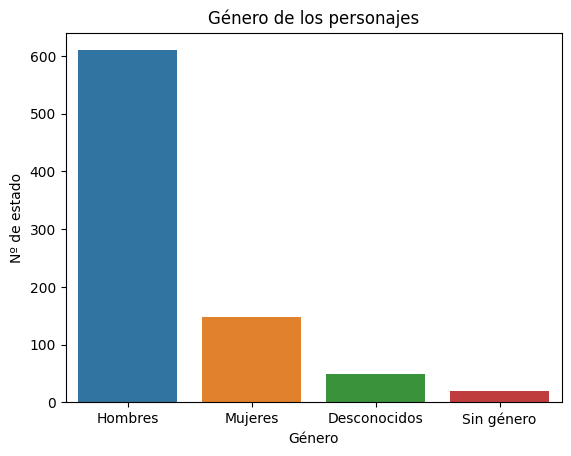

In [84]:
aux_df_characters = originial_characters[["status", "gender"]]

sns.countplot(data= aux_df_characters, x="gender", hue="gender")
plt.xticks([0, 1, 2, 3], ["Hombres", "Mujeres", "Desconocidos", "Sin género"])
plt.title("Género de los personajes")
plt.xlabel("Género")
plt.ylabel("Nº de estado")

plt.show()

- ### Genero de los personajes (con estado)
  De aqui podemos inferir no sólo que genero es el más común entre todos los personajes sino el estado mas común por género

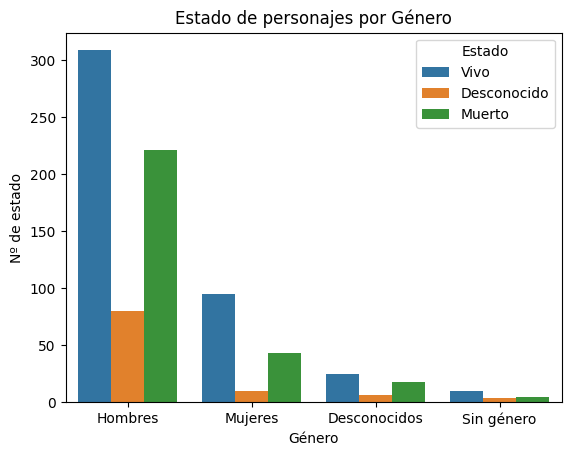

In [85]:

aux_df_characters = originial_characters[["status", "gender"]]

order = aux_df_characters["gender"].value_counts()

sns.countplot(data= aux_df_characters, x="gender", hue="status")
plt.xticks([0, 1, 2, 3], ["Hombres", "Mujeres", "Desconocidos", "Sin género"])

plt.legend(labels=["Vivo", "Desconocido", "Muerto"], title="Estado")

plt.title("Estado de personajes por Género")
plt.xlabel("Género")
plt.ylabel("Nº de estado")
plt.show()

- ### Muertes por género (Estado por género)

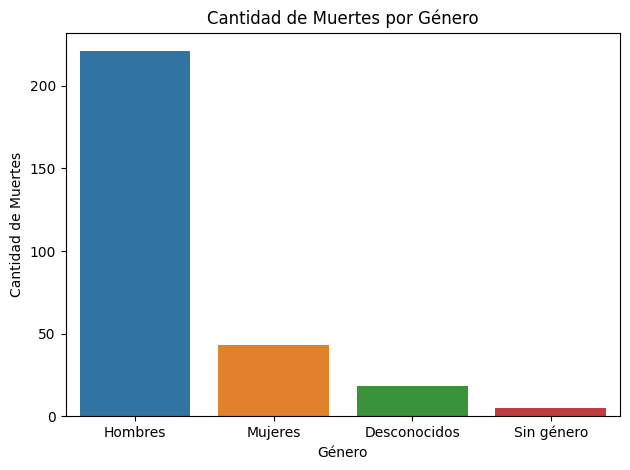

In [86]:
# Contar muertes por género
df_dead_gen = df_characters[df_characters["status"] == "Dead"][["name", "status", "gender"]]
#Se recoge la cantidad de muertes por genero y lo pasamos a dataframe:
muertes_por_genero = df_dead_gen["gender"].value_counts().reset_index()
#Renombra las columnas:
muertes_por_genero.columns = ["gender", "count"]
# Graficar
sns.barplot(data=muertes_por_genero, x="gender", hue="gender", y="count")
plt.title("Cantidad de Muertes por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad de Muertes")
plt.xticks([0, 1, 2, 3], ["Hombres", "Mujeres", "Desconocidos", "Sin género"])
plt.tight_layout()
plt.show()

## Estudio de localizaciones (_df_locations_)


- ### TOP 10 localizaciones más peligrosas

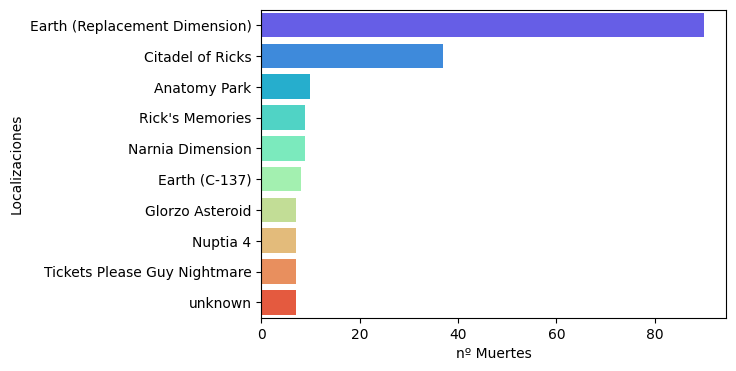

In [87]:
top10kill = df_characters[df_characters["status"]=="Dead"].groupby("location_nueva")["status"].count().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize = (6, 4))

sns.barplot(y=top10kill.index,x=top10kill.values,hue=top10kill.index,palette="rainbow")
plt.ylabel("Localizaciones")
plt.xlabel("nº Muertes")
plt.show()

- ### Distrubicion de la muerte por especie en las 5 localizaciones más peligrosas
  De las 5 localizaciones con más número de muertes que número son de cada especie

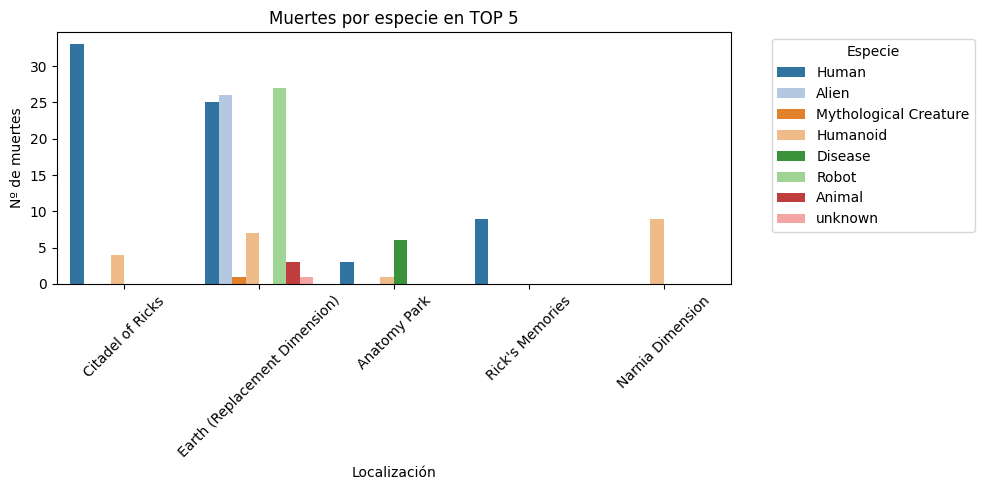

In [97]:
df_dead = df_characters[df_characters["status"] == "Dead"][["name", "status", "species","location_nueva"]]
top5_locations = df_dead["location_nueva"].value_counts().head(5).index
df_top5 = df_dead[df_dead["location_nueva"].isin(top5_locations)]

plt.figure(figsize=(10, 5))
sns.countplot(data=df_top5, x="location_nueva", hue="species", palette="tab20")

plt.title("Muertes por especie en TOP 5")
plt.xlabel("Localización")
plt.ylabel("Nº de muertes")
plt.xticks(rotation=45 , ticks=[0,1,2,3,4])
plt.legend(title="Especie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Estudio de episodios (_df_episodes_)

- ### Personajes con más apariciones por episodio

/tmp/ipykernel_3473/1845993437.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_char["name"] = [dict_character_id[id]["name"] for id in to_char["id"]]
/tmp/ipykernel_3473/1845993437.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_char["status"] = [dict_character_id[id]["status"] for id in to_char["id"]]
/tmp/ipykernel_3473/1845993437.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

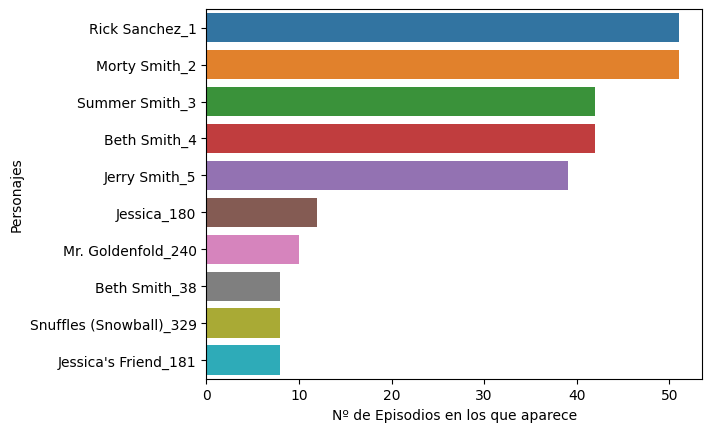

In [92]:

originial_characters["n_app"] = [len(episode_list) for episode_list in originial_characters["episode"]]

to_char = None

to_char = originial_characters[["n_app", "id"]]

def make_unique_key(id):
 id_p = dict_character_id[id]["id"]
 name = dict_character_id[id]["name"]
 toret = name + "_" + str(id_p) 
 return toret

to_char["name"] = [dict_character_id[id]["name"] for id in to_char["id"]]
to_char["status"] = [dict_character_id[id]["status"] for id in to_char["id"]]
to_char["origin"] = [dict_character_id[id]["origin"]["name"] for id in to_char["id"]]
to_char["name+id"] = [make_unique_key(id) for id in to_char["id"]]

to_char= to_char.sort_values(by="n_app", ascending=False)

sns.barplot(data=to_char[:10], y="name+id", x="n_app",hue="name+id")
plt.xlabel("Nº de Episodios en los que aparece")
plt.ylabel("Personajes")
plt.show()

- ### Personajes con más apariciones por episodio ( sin contar la familia Smith)

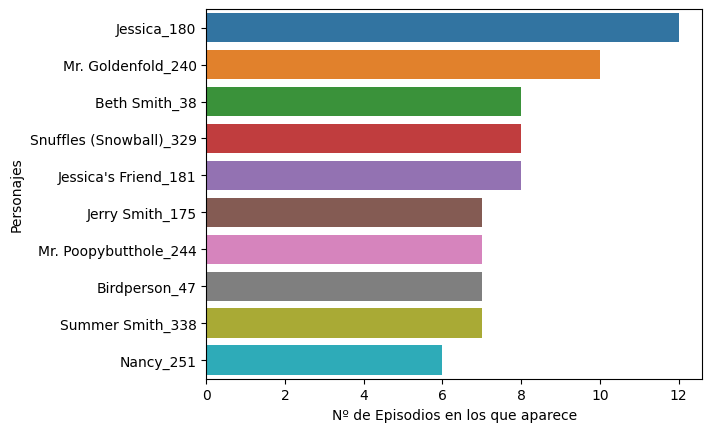

In [93]:
axu_to_char = to_char[5:]

axu_to_char= axu_to_char.sort_values(by="n_app", ascending=False)

sns.barplot(data=axu_to_char[:10], y="name+id", x="n_app", hue="name+id")
plt.xlabel("Nº de Episodios en los que aparece")
plt.ylabel("Personajes")
plt.show()


- ### Episodios cannon (donde aparecen Evil Rick o Evil Morty)

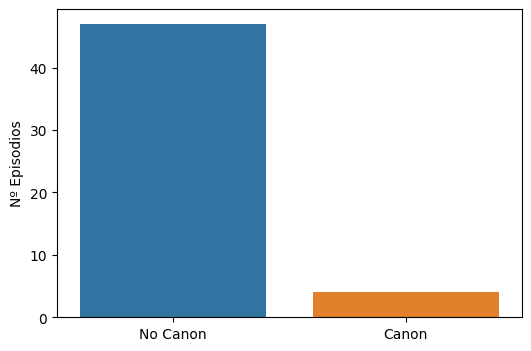

In [94]:
fig, ax = plt.subplots(figsize = (6, 4))

villanos=("Evil Rick","Evil Morty")

id_canon=df_episodes[df_episodes["characters"].apply(lambda celda:any(vil in celda for vil in villanos))]["id"]

df_episodes["canon"] = df_episodes["id"].isin(id_canon)
sns.countplot(data=df_episodes,x="canon", hue="canon")

plt.legend().remove()
plt.xlabel("")
plt.ylabel("Nº Episodios")
plt.xticks(ticks=[0,1], labels=["No Canon", "Canon"])
plt.show()

- ### Géneros con más apariciones por episodio
  Se ve que personaes salen por episodio (repetidos también) y contamos sus géneros, además tb incluimos el estado para ver cuantos de los personajes de ese género estan muertos vivos o en paradero desconocido

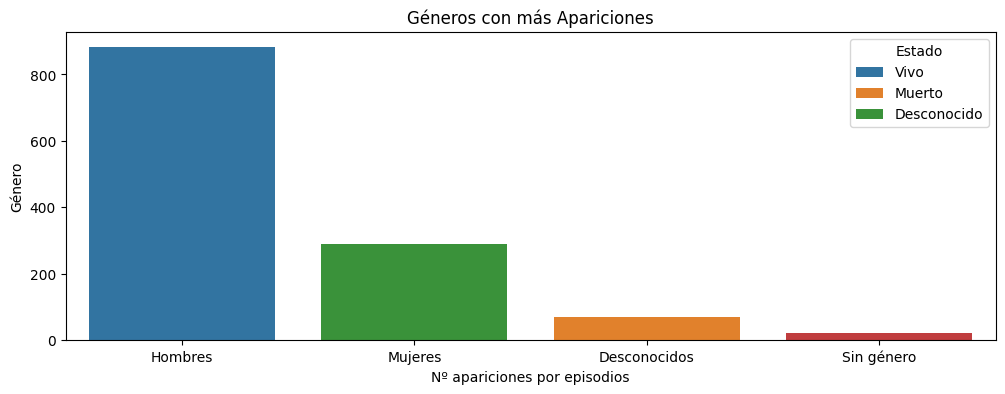

In [95]:

originial_episodes["nº_chars"] = [ len(n_char) for n_char in originial_episodes["characters"]]

num_total_de_apariciones_personajes = originial_episodes["nº_chars"].sum()

aux_df_episodes = originial_episodes.explode("characters_id")

aux_df_episodes["gender"] = aux_df_episodes["characters_id"].apply(lambda id: dict_character_id[id]["gender"])
aux_df_episodes["status"] = aux_df_episodes["characters_id"].apply(lambda id: dict_character_id[id]["status"])

order = aux_df_episodes["gender"].value_counts().index.to_list()

# Gráfico de barras sin estado
plt.figure(figsize=(12, 4))

#Grafica con solo genero
sns.countplot(data=aux_df_episodes[["gender"]], x="gender", hue="gender", order=order)
plt.xlabel("Nº apariciones por episodios")
plt.ylabel("Género")
plt.title("Géneros con más Apariciones")
plt.xticks([0, 1, 2, 3], ["Hombres", "Mujeres", "Desconocidos", "Sin género"])
plt.legend(labels=["Vivo", "Muerto", "Desconocido"], title="Estado")
plt.show()

- ### Géneros con más apariciones por episodio (con estado)

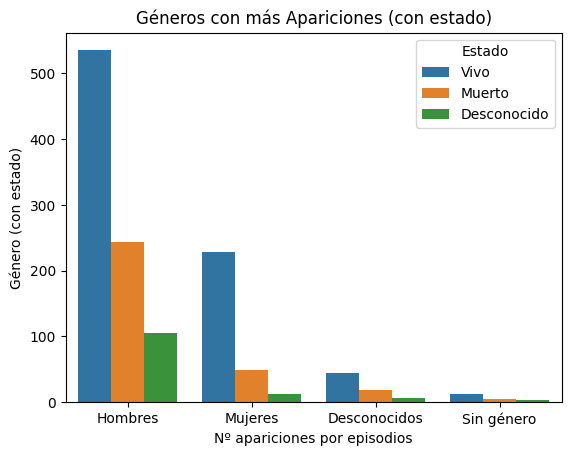

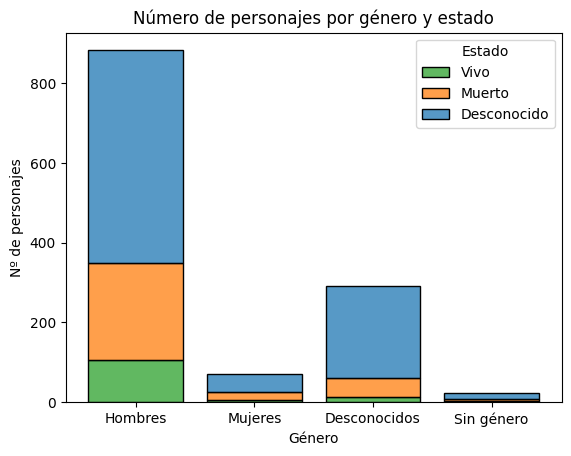

In [96]:
#Por estado aparte de genero
sns.countplot(data=aux_df_episodes[["gender", "status"]], x="gender", hue="status", order=order)
plt.xlabel("Nº apariciones por episodios")
plt.ylabel("Género (con estado)")
plt.title("Géneros con más Apariciones (con estado)")
plt.xticks([0, 1, 2, 3], ["Hombres", "Mujeres", "Desconocidos", "Sin género"])

plt.legend(labels=["Vivo", "Muerto", "Desconocido"], title="Estado")

plt.show()

#Grafica stacked
sns.histplot(
    data=aux_df_episodes[["gender", "status"]],
    x="gender",
    hue="status",
    multiple="stack",
    shrink=0.8,
    stat="count"
)
plt.xticks([0, 1, 2, 3], ["Hombres", "Mujeres", "Desconocidos", "Sin género"])
plt.legend(labels=["Vivo", "Muerto", "Desconocido"], title="Estado")
plt.title("Número de personajes por género y estado")
plt.ylabel("Nº de personajes")
plt.xlabel("Género")

plt.show()

- ### Temporadas más mortales

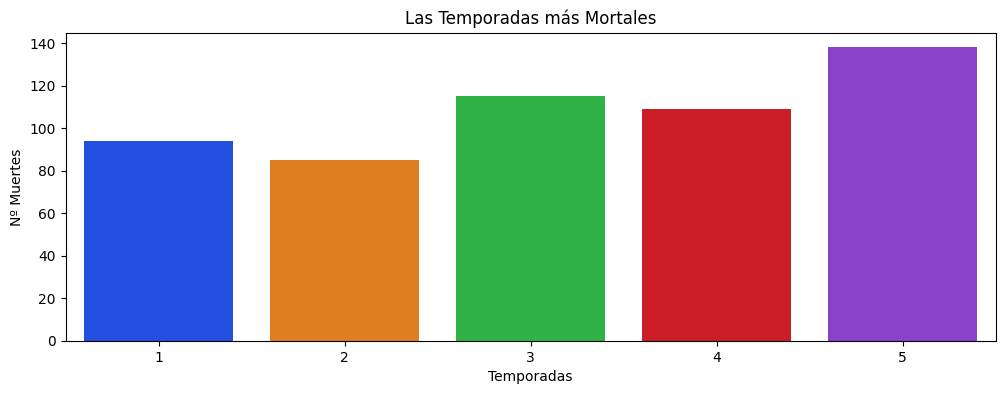

In [106]:
fig, ax = plt.subplots(figsize = (12, 4))

df_dead = df_characters[df_characters["status"] == "Dead"][["name", "status", "species"]]
df_duracion_vida = df_episodes[["season","episode_season", "characters"]].explode("characters")
df_relacionado = pd.merge(df_dead, df_duracion_vida, left_on="name", right_on="characters")
df_relacionado = df_relacionado.sort_values(["name", "season","episode_season"])

df_relacionado.groupby("season")["status"].count()
sns.barplot(x=df_relacionado.groupby("season")["status"].count().index,
            y=df_relacionado.groupby("season")["status"].count().values,
            hue=df_relacionado.groupby("season")["status"].count().index,
            palette="bright")

plt.title("Las Temporadas más Mortales")
plt.xlabel("Temporadas")
plt.ylabel("Nº Muertes")
plt.legend().remove()

plt.show()

- ### Capítulos con mas muertes

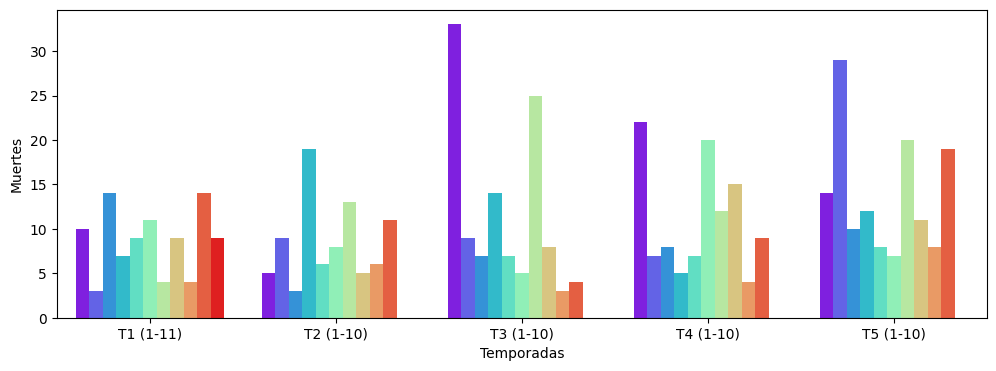

In [ ]:

fig, ax = plt.subplots(figsize = (12, 4))

top10caps=df_relacionado.groupby(["season","episode_season"])["status"].count().sort_values(ascending=False)

df = pd.DataFrame(top10caps)
sns.barplot( data = pd.DataFrame(top10caps), x = "season", y = "status", hue="episode_season", palette="rainbow")

# los nombres del hue (leyenda)
plt.legend(title='Episodio').remove()

plt.xlabel("Temporadas")

plt.ylabel("Muertes")

plt.xticks(ticks=[0, 1, 2, 3, 4], labels=["T1 (1-11)", "T2 (1-10)", "T3 (1-10)", "T4 (1-10)", "T5 (1-10)"])

plt.show()


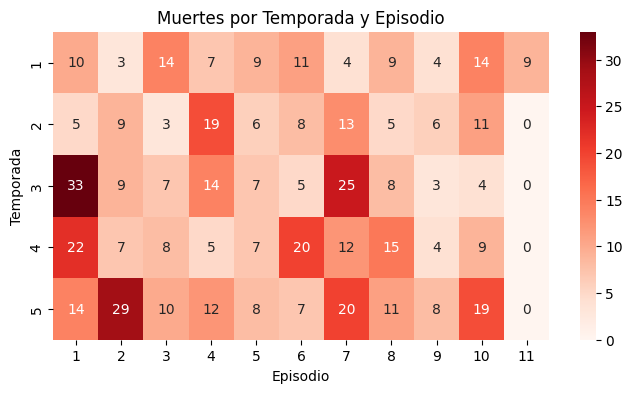

In [77]:

heat_caps = top10caps.reset_index().pivot(index='season', columns='episode_season', values='status').fillna(0)

plt.figure(figsize=(8,4))
sns.heatmap(heat_caps, annot=True, cmap='Reds')

plt.title("Muertes por Temporada y Episodio")
plt.xlabel("Episodio")
plt.ylabel("Temporada")
plt.show()

- ### Muertes en episodios _canon_

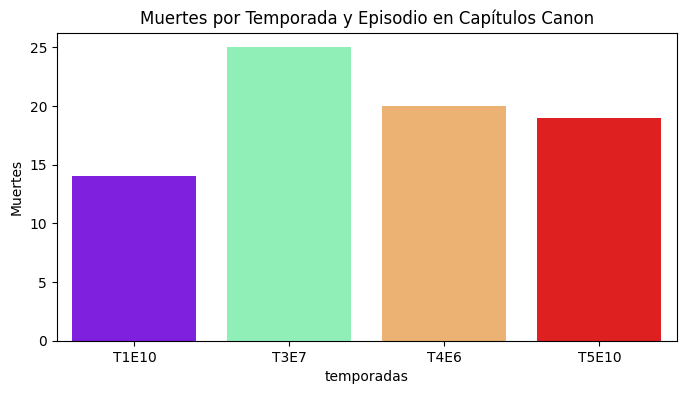

In [110]:
villanos=("Evil Rick","Evil Morty")

id_canon=df_episodes[df_episodes["characters"].apply(lambda celda:any(vil in celda for vil in villanos))]["id"]

df_episodes["canon"] = df_episodes["id"].isin(id_canon)
df_capscanon = df_episodes[["season","episode_season", "characters","canon"]].explode("characters")
df_status = df_characters[["name", "status", "species"]]
df_relacionado2 = pd.merge(df_status, df_capscanon, left_on="name", right_on="characters")
muertes_canon=df_relacionado2[df_relacionado2["status"]=="Dead"].groupby(["species","canon"])["name"].count()

muertes_canon2=(df_relacionado2[(df_relacionado2["status"]=="Dead")&(df_relacionado2["canon"]==True)]
                .groupby(["episode_season","season"])["name"]
                .count()
                .reset_index()
                .sort_values(by="episode_season"))

fig, ax = plt.subplots(figsize = (8, 4))

sns.barplot(data=muertes_canon2,x="season",y="name",hue="season", palette="rainbow")

plt.legend(title='capitulo').remove()
plt.xticks(ticks=[0,1,2,3], labels=["T1E10", "T3E7", "T4E6", "T5E10"])
plt.title("Muertes por Temporada y Episodio en Capítulos Canon")
plt.xlabel("temporadas")
plt.ylabel("Muertes")


plt.show()


- ### Estudio del capítulo más mortal
  Como se aprecia en el capítulo más mortal de la serie se aprecia que en estos capitulos mueren casi tantos humanos como los que sobreviven pero también se aprecia como en la primera grafica que la raza con mas mortalidad es la robot ya que no hay ninguno que sobreviva en este capitulo

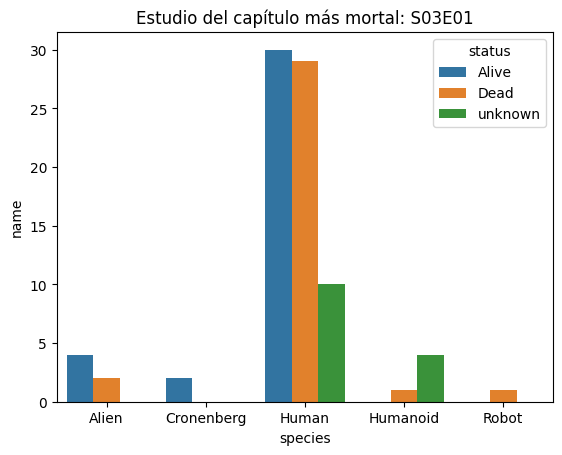

In [ ]:
df_status = df_characters[["name", "status", "species"]]
df_relacionado1 = pd.merge(df_status, df_duracion_vida, left_on="name", right_on="characters")
df_capmortal=df_relacionado1[(df_relacionado1["season"]==3)&(df_relacionado1["episode_season"]==1)]

capmortalcount=df_capmortal.groupby(["status","species"])["name"].count()
sns.barplot(data = pd.DataFrame(capmortalcount),x="species",y="name",hue="status")

plt.title("Estudio del capítulo más mortal: S03E01")

plt.show()

x = pd.DataFrame(capmortalcount)

- ### Mortalidad en capitulos canon
  Estudiamos las muertes en los capitulos canon comparados a los normales y podemos apreciar que aunque hay un numero de muertes,sobretodo humanas muy elevado al ser un numero tan pequeño de capitulos la cantidad es muy pequeña en comparacion al resto de capitulos de la serie donde si hay muertes de todos los tipos de especies aunque dominen las muertes de humanos

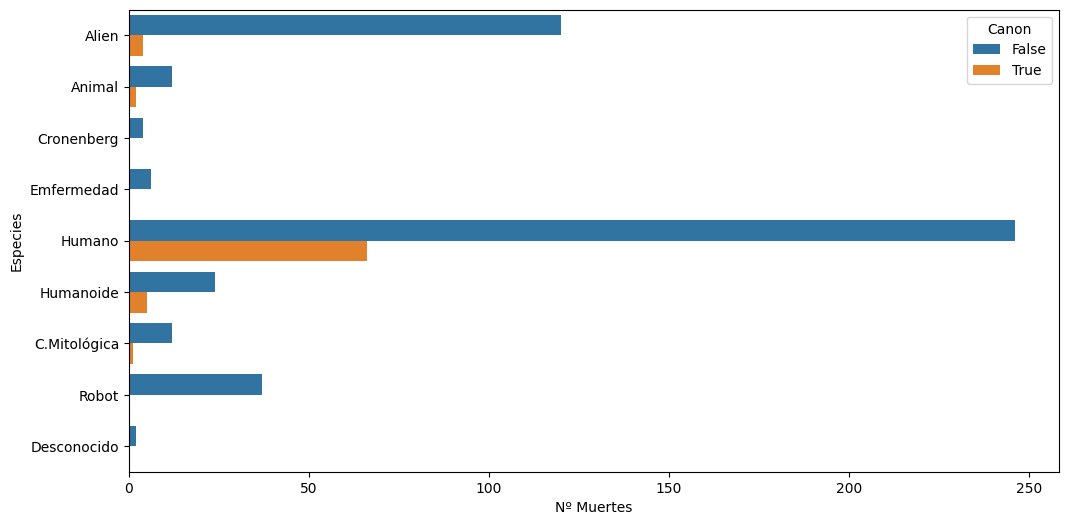

In [ ]:
villanos=("Evil Rick","Evil Morty")

id_canon=df_episodes[df_episodes["characters"].apply(lambda celda:any(vil in celda for vil in villanos))]["id"]

df_episodes["canon"] = df_episodes["id"].isin(id_canon)
df_capscanon = df_episodes[["season","episode_season", "characters","canon"]].explode("characters")
df_status = df_characters[["name", "status", "species"]]
df_relacionado2 = pd.merge(df_status, df_capscanon, left_on="name", right_on="characters")
muertes_canon=df_relacionado2[df_relacionado2["status"]=="Dead"].groupby(["species","canon"])["name"].count()

fig, ax = plt.subplots(figsize = (12, 6))

sns.barplot(data=pd.DataFrame(muertes_canon),hue="canon",x="name",y="species")

plt.legend(title='Canon')

plt.yticks(ticks=[0,1,2,3,4,5,6,7,8], labels=["Alien", "Animal", "Cronenberg", "Emfermedad", "Humano", "Humanoide", "C.Mitológica", "Robot", "Desconocido"]) 

plt.ylabel("Especies")
plt.xlabel("Nº Muertes")
plt.show()

### Análisis extra de mortalidad rick y morty

Con este analisis comparamos la mortalidad de todas las versiones de rick y morty con  los humanos para revisar que ser cualquier version de rick y morty que no es la protagonista tiene una tasa de mortalidad bastante alta

Además cuadra con el grafico de localizaciones más muertes donde la segunda es ciudadela ,locaclizacion de la mayoria de ricks y mortys

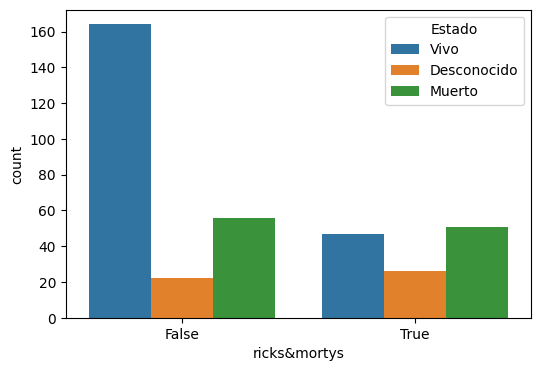

In [116]:
fig, ax = plt.subplots(figsize = (6, 4))

id_ricks=df_characters[(df_characters["name"].str.contains("Rick"))|(df_characters["name"].str.contains("Morty"))]["id"]
df_characters["ricks&mortys"] = df_characters["id"].isin(id_ricks)

sns.countplot(data=df_characters[df_characters["species"]=="Human"],hue="status",x="ricks&mortys")

plt.legend(title='Estado', labels=["Vivo", "Desconocido", "Muerto"])


plt.show()


  Todo apunta a que si eres un Rick o Morty pero no eres protagonista en un capítulo *canon* es muy probable que tu no vayas a durar mucho :(